# **Instructions to Run**

1. Upload desired number of images to colab from example data. Keep images in the folders referencing their leaf type. Using all 30 of each leaf will only take one minute to run feature extraction on in total.
2. Update folder name in the fifth box below to the folder name containing the leaves.
3. Run all boxes sequentially.

In [3]:
# Computer Vision Course (CSE 40535)
#
# Semester Project -- Leaf Classification
#
# Author: Xavier Reese 2024
#
# Part 3 -- Pre-Processing, Segmentation & Feature Extraction

In [2]:
#@title Google Drive
#from google.colab import drive
#drive.mount('/content/drive')

In [292]:
!apt-get install python3.5
#!pip uninstall -y opencv-python-headless opencv-python opencv-contrib-python
#!pip install opencv-python-headless==4.5.5.62+contrib-cuda -f https://download.opencv.org/releases.html
#!pip install opencv-python==4.8.1.78
!apt-get update
!apt-get install -y python3.5 # Install python 3.5 if needed by your project

# Install system dependencies for CUDA
!apt-get install -y --no-install-recommends \
    cuda-11-8 \
    libcublas-11-8 \
    libcudnn8

# Uninstall conflicting versions of OpenCV if they exist
!pip uninstall -y opencv-python-headless opencv-python opencv-contrib-python

# Install OpenCV with CUDA support
#!pip install opencv-python-headless==4.5.5.62+contrib-cuda -f https://download.opencv.org/releases.html
!pip install opencv-python-headless[cuda]

import numpy as np
import math
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import skimage.measure as measure

print(cv2.__version__)
print("CUDA Support in OpenCV:", cv2.cuda.getCudaEnabledDeviceCount() > 0)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
Note, selecting 'libpython3.5-stdlib' for regex 'python3.5'
Note, selecting 'libpython3.5-minimal' for regex 'python3.5'
0 upgraded, 0 newly installed, 0 to remove and 55 not upgraded.
Get:1 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy

4.10.0
CUDA Support in OpenCV: False


In [293]:
## IMPORT IMAGES

import glob

orig_leaves = {}
path = "/content/drive/MyDrive/healthy/*" ### <=== UPDATE THIS TO DESIRED FOLDER
for folder in glob.glob(path):
    folder_name = folder.split('/')[-1]
    print('importing: ', folder_name)
    orig_leaves[folder_name] = []
    i = 0
    for img in glob.glob(folder+"/*"):
        i+=1
        print(i)
        if(i == 30): break
        orig_leaves[folder_name].append(cv2.imread(img))
    print('-- done --')

importing:  Apple
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Cherry
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Soybean
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Pepper
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Grape
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Peach
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Blueberry
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Raspberry
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done --
importing:  Potato
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
-- done 

In [ ]:
#################################
#@title GENERAL USE HELPER FUNCTIONS

def equalize(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.equalizeHist(gray)

def equalize_clahe_gray(gray_img):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    return clahe.apply(gray_img)

def equalize_clahe(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return equalize_clahe_gray(gray)


In [294]:
################################
#@title EXTRACT BINARY THRESH OF LEAF

def binary_leaf_green_rgb(image):
    r, g, b = cv2.split(image)
    # Threshold -> Binary of Leaf (green only)
    ret_leaf, thresh_leaf = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return ret_leaf, thresh_leaf

def binary_leaf_green_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # Threshold -> Binary of Leaf (green only)
    lower_bounds = np.array([35, 20, 0])
    upper_bounds = np.array([100, 255, 255])
    mask = cv2.inRange(hsv, lower_bounds, upper_bounds)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel=np.ones((5,5), np.uint8))

    return mask

def binary_leaf_grey(image):
    gray = equalize(image)
    gray = equalize_clahe(image)
    # Threshold -> Binary of Leaf
    ret_leaf, thresh_leaf = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return ret_leaf, thresh_leaf

def binary_shadow(image):
    se_size = 2  # size of your structuring element (morphological operation kernel) -- try something between 5 and 15
    se = np.ones((se_size,se_size), np.uint8)
    gray = equalize_clahe(image)

    ret_shadow, thresh_shadow = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY_INV)

    # bounds for shadow
    shadow_lower_bounds = np.array([0, 0, 0])
    shadow_upper_bounds = np.array([255, 90, 30])

    # Erode & Dilate
    thresh_shadow = cv2.morphologyEx(thresh_shadow, cv2.MORPH_ERODE, kernel=se)
    thresh_shadow = cv2.morphologyEx(thresh_shadow, cv2.MORPH_DILATE, kernel=se)

    return ret_shadow, thresh_shadow




In [ ]:
###################
#@title REMOVE SHADOWS

def shadow_mask(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Threshold to isolate non-shadow areas (higher Value)
    _, mask = cv2.threshold(hsv_image[:, :, 2], 30, 255, cv2.THRESH_BINARY)

    #plt.imshow(mask, cmap='gray')
    #plt.show()
    return mask


In [295]:
#@title BINARY LEAF USING EDGE DETECTION

def edge_leaf_adaptive(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)
    adaptive_thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
    median_blurred = cv2.medianBlur(adaptive_thresh, 7) # less noise
    edges = cv2.Canny(median_blurred, 50, 150)

    ## Show Adaptive Threshold Steps
    '''
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(adaptive_thresh, cmap='gray')
    plt.title("Adaptive Threshold")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(median_blurred, cmap='gray')
    plt.title("Median Blur")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected")
    plt.axis("off")

    plt.show()
    '''

def edge_leaf(image):
    blurred_image = cv2.GaussianBlur(image, (5, 5), 0)
    gray = cv2.cvtColor(blurred_image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(blurred_image, threshold1=100, threshold2=200)
    without_shadow = cv2.bitwise_and(edges, shadow_mask(image))

    ## Show Edge Detection Steps
    '''
    plt.figure(figsize=(10,5))
    plt.subplot(1, 4, 1)
    plt.imshow(image, cmap='gray')
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(edges, cmap='gray')
    plt.title("Edges Detected")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(without_shadow, cmap='gray')
    plt.title("Without Shadows")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(gray, cmap='gray')
    plt.title("Gray Image")
    plt.axis("off")

    plt.show()
    '''

In [296]:
####################
#@title Post-Binarization

def remove_stems(img):
    kernel = np.ones((10, 10), np.uint8)
    opened_image = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(opened_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    leaf_bin = np.zeros_like(img)
    for contour in contours:
        if cv2.contourArea(contour) > 500:
            cv2.drawContours(leaf_bin, [contour], -1, 255, thickness=cv2.FILLED)
            break

    return leaf_bin

In [297]:
############################
#@title Extract Features

from skimage.feature import local_binary_pattern, graycomatrix, graycoprops

def extract_features(bin_img, orig_img):
    features = dict()

    contours, _ = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    perimeter = cv2.arcLength(contours[0], True)
    with_perimeter = cv2.drawContours(orig_img.copy(), contours, -1, (0, 255, 0), 3)
    features['perimeter'] = perimeter

    c_hull = find_convex_hull(contours)
    features['area'] = cv2.contourArea(c_hull)
    features['perimeter'] = cv2.arcLength(c_hull, True)

    area_shape = cv2.contourArea(max(cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0], key=cv2.contourArea))
    features['solidity'] = float(area_shape) / features['area'] if features['area'] != 0 else 0

    features['major_axis_length'], features['minor_axis_length'] = major_minor_axis(bin_img, c_hull)
    features['aspect_ratio'] = features['major_axis_length'] / features['minor_axis_length']

    features.update(extract_texture_features(orig_img, bin_img))
    features.update(extract_color_features(orig_img, bin_img))

    return features

def find_convex_hull(contours):
    largest_contour = max(contours, key=cv2.contourArea)
    hull = cv2.convexHull(largest_contour)

    return hull

def major_minor_axis(bin_img, convex_hull):
    binary_convex = np.zeros_like(bin_img)
    cv2.drawContours(binary_convex, [convex_hull], -1, 255, thickness=cv2.FILLED)

    # Pad image so if binary leaf goes over edge, we don't get multiple labels for background

    binary_convex_padded = np.pad(binary_convex, pad_width=1, mode='constant', constant_values=0)
    labels_padded = measure.label(binary_convex_padded)
    labels = labels_padded[1:-1, 1:-1] # un-pad

    # Measure Features
    features = measure.regionprops(labels)

    return features[0].major_axis_length, features[0].minor_axis_length

def extract_color_features(orig_img, bin_img):
    leaf_region = cv2.bitwise_and(orig_img, orig_img, mask=bin_img)
    hsv = cv2.cvtColor(leaf_region, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    average_h = np.mean(h)
    average_s = np.mean(s)
    average_v = np.mean(v)

    return {'average_h': average_h, 'average_s': average_s, 'average_v': average_v}


def extract_texture_features(orig_img, bin_img):
    gray_image = cv2.cvtColor(orig_img, cv2.COLOR_BGR2GRAY)
    gray_image = equalize_clahe_gray(gray_image)
    leaf_region = cv2.bitwise_and(gray_image, gray_image, mask=bin_img)

    ## Plot shown in README
    #plt.subplot(2, 3, 5)
    #plt.imshow(leaf_region, cmap="gray")

    #gpu_leaf_region = cv2.cuda_GpuMat()
    #gpu_leaf_region.upload(leaf_region)

    ### Gray-Level Co-Occurrence Matrix (GLCM) Features

    distances = [1, 3, 5]
    angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 0, 45, 90, 135

    glcm = graycomatrix(leaf_region, distances=distances, angles=angles, levels=256, symmetric=True, normed=True)

    contrast = graycoprops(glcm, 'contrast').mean()
    dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()
    energy = graycoprops(glcm, 'energy').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    asm = graycoprops(glcm, 'ASM').mean()

    glcm_features = {'contrast': contrast, 'dissimilarity': dissimilarity, 'homogeneity': homogeneity, 'energy': energy, 'correlation': correlation, 'ASM': asm}

    ### Local Binary Pattern (LBP) Features

    radius = 3
    n_points = 8 * radius

    lbp = local_binary_pattern(leaf_region, n_points, radius, method="uniform")

    (lbpn, _) = np.histogram(lbp.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))
    lbp_hist = lbpn.astype("float")
    lbp_hist /= (lbp_hist.sum())

    ### Gabor Filter Features

    num_orientations = 8

    gabor_means = []
    gabor_std = []
    filtered_max = np.zeros_like(bin_img)

    #height, width = bin_img.shape
    #gpu_filtered_or_img = cv2.cuda_GpuMat()
    #gpu_filtered_or_img.create((height, width), cv2.CV_8UC1)

    for theta in np.arange(0, np.pi, np.pi / num_orientations):
        if theta == np.pi / 4 or theta == 3 * np.pi / 4: continue  # skip 45 degree angles - much more difficult to tune and line features were picked up without them

        # Define Parameters
        sigma = 5
        ksize = 9 if theta == 0 or theta == np.pi / 2 else 13
        gamma = 0.01
        lambda_ = 5
        kernel = cv2.getGaborKernel((ksize, ksize), sigma, theta, 8.0, 0.5, 0, ktype=cv2.CV_32F)

        # Perform Filter
        filtered = cv2.filter2D(leaf_region, cv2.CV_8UC3, kernel)

        #gpu_filtered = cv2.cuda.filter2D(gpu_leaf_region, -1, cv2.cuda_Kernel(kernel))
        '''
        print("sigma", sigma, "theta", theta, "lambda", lambda_, "gamma", gamma, "ksize", ksize)
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(kernel, cmap='gray')
        plt.colorbar()
        plt.axis("off")
        plt.subplot(1, 2, 2)
        plt.imshow(filtered, cmap='gray')
        plt.colorbar()
        plt.axis("off")
        plt.show()
        '''


        ## Max Results Together

        #filtered_and_bin = cv2.bitwise_or(filtered_and_bin, filtered, mask=bin_img)
        filtered_max = cv2.max(filtered_max, filtered)
        #gpu_filtered_or_img = cv2.cuda.bitwise_or(gpu_filtered_or_img, gpu_filtered, mask=gpu_leaf_region)
        mean, std_dev = cv2.meanStdDev(filtered, mask=bin_img)
        gabor_means.append(mean[0][0])
        gabor_std.append(std_dev[0][0])

    #filtered_max = gpu_filtered_or_img.download()

    ## Erode leaf edge and find mean/std of vein skeleton

    eroded_bin = cv2.erode(bin_img, np.ones((9, 9), np.uint8), iterations=1)
    filtered_max = cv2.bitwise_and(filtered_max, filtered_max, mask=eroded_bin)
    max_std, max_mean = cv2.meanStdDev(filtered_max, mask=eroded_bin)
    gabor_features = {'gabor_mean_sum': sum(gabor_means), 'gabor_std_sum': sum(gabor_std), 'gabor_mean_max': max_mean[0][0], 'gabor_std_max': max_std[0][0]}


    ## Show Vein Skeleton
    #cv2_imshow(filtered_max)

    ## Plot shown in README
    #plt.subplot(2, 3, 6)
    #plt.imshow(filtered_max, cmap="gray")

    all_features = {**glcm_features, **gabor_features, 'lbp_hist': lbp_hist}
    return all_features





In [298]:
#########################
#@title Final Functions

def binary_thresh_leaf(bin_img, orig_img):
    print("ORIGINAL:")
    cv2_imshow(bin_img)

    ret_leaf, thresh_leaf = binary_leaf_grey(bin_img)
    ret_shadow, thresh_shadow = binary_shadow(bin_img)

    print("LEAF")
    cv2_imshow(thresh_leaf)
    print("SHADOW")
    cv2_imshow(thresh_shadow)

    thresh = cv2.subtract(thresh_leaf, thresh_shadow)
    print("FINAL")
    cv2_imshow(thresh)

def binary_leaf_hsv(bin_img):
    #cv2_imshow(bin_img)
    green = binary_leaf_green_hsv(bin_img)
    #plt.subplot(2, 3, 2)
    #plt.imshow(green, cmap="gray")
    without_stems = remove_stems(green)
    return without_stems




Apple
Cherry
Soybean
Pepper
Grape
Peach
Blueberry
Raspberry
Potato
Strawberry
Tomato


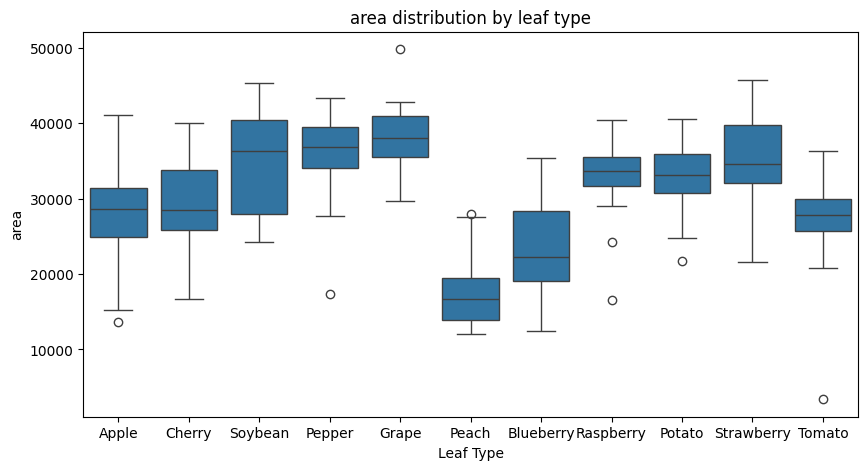

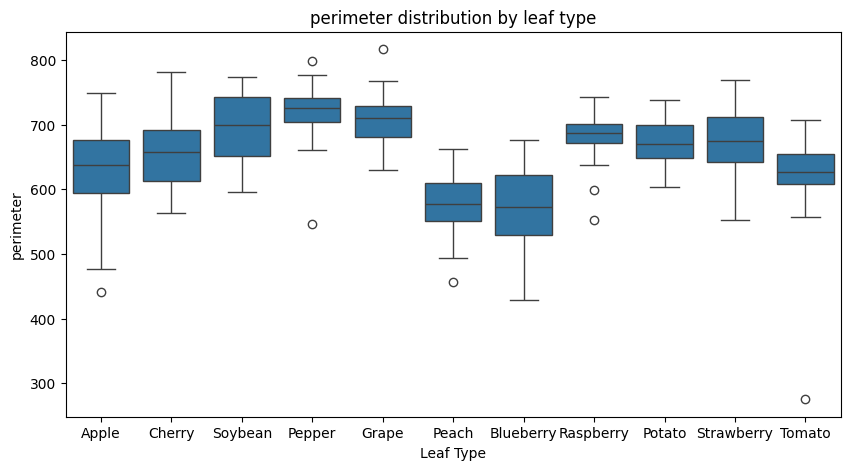

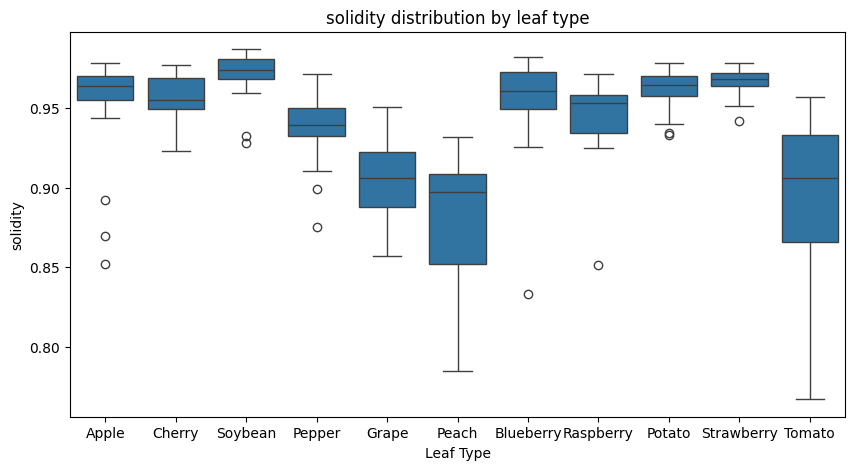

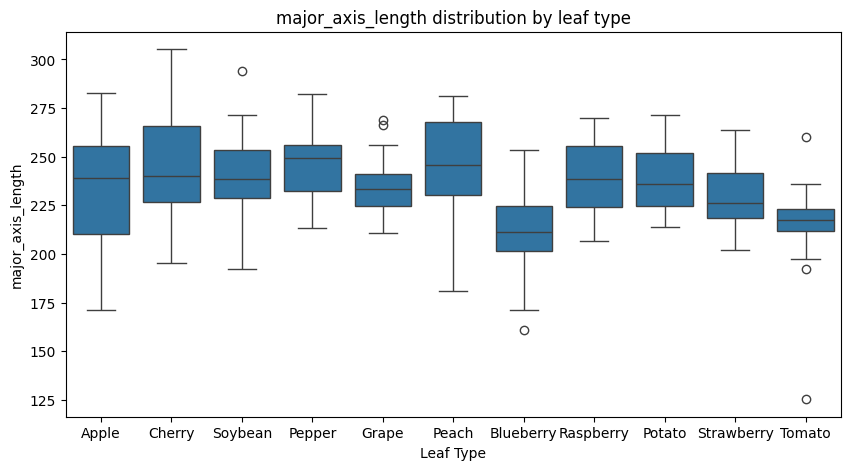

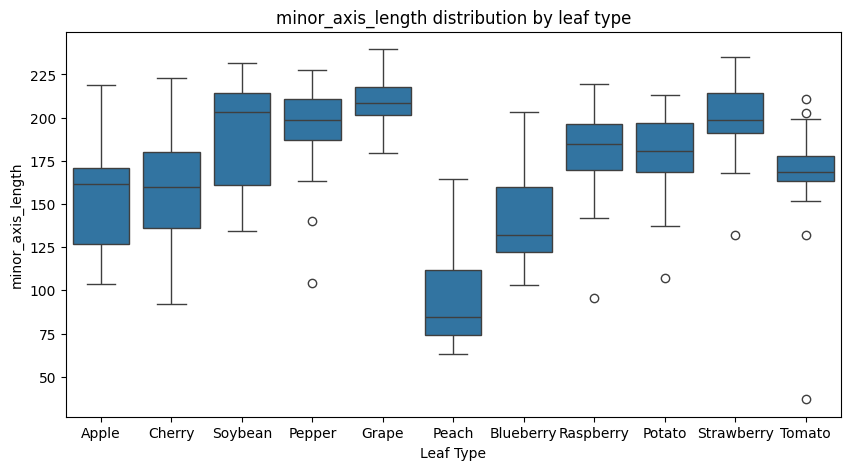

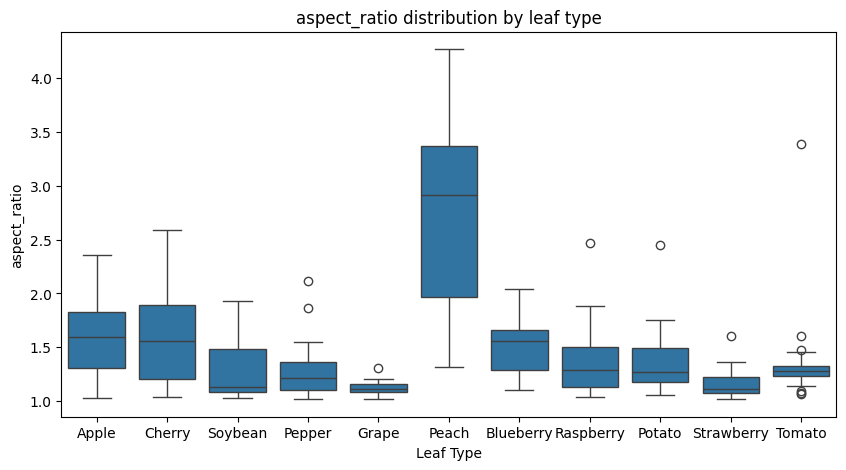

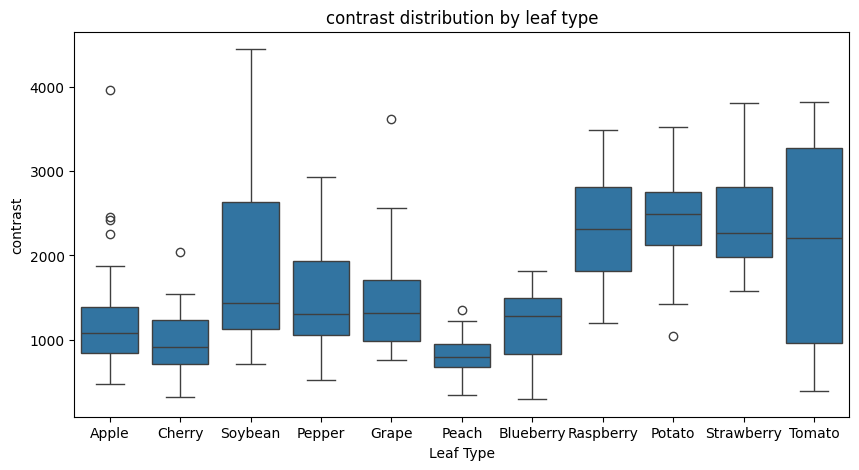

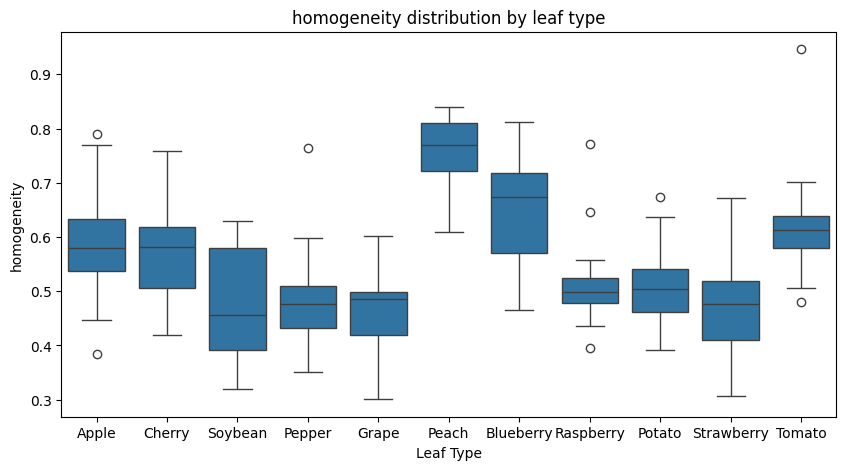

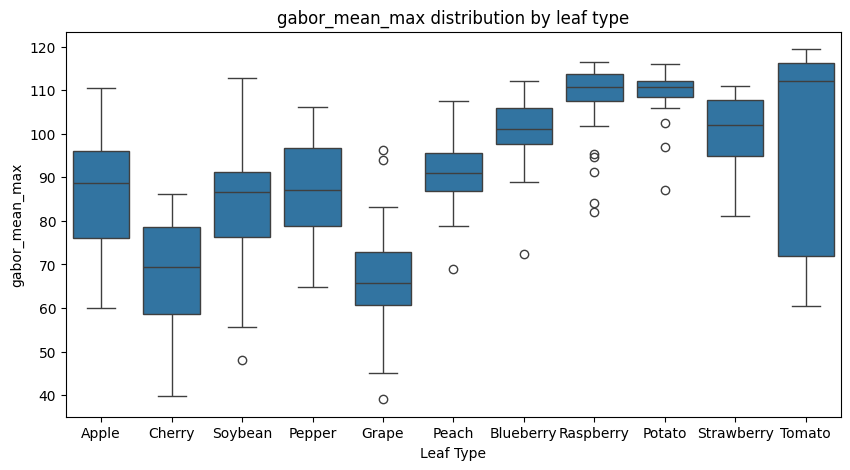

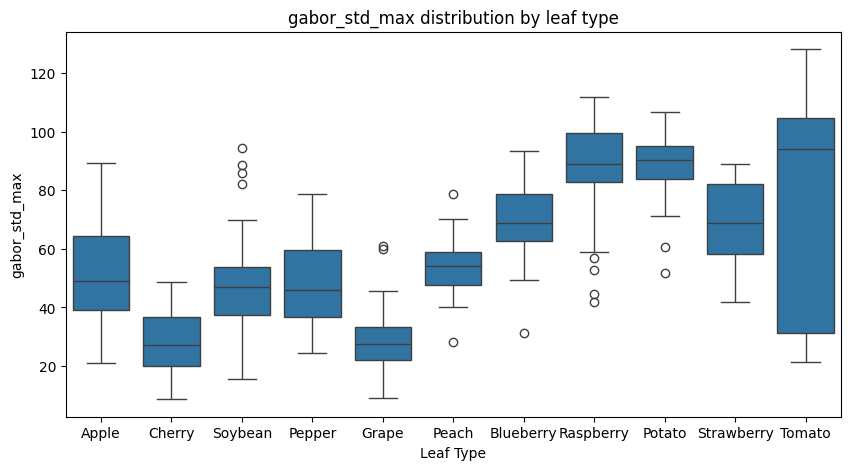

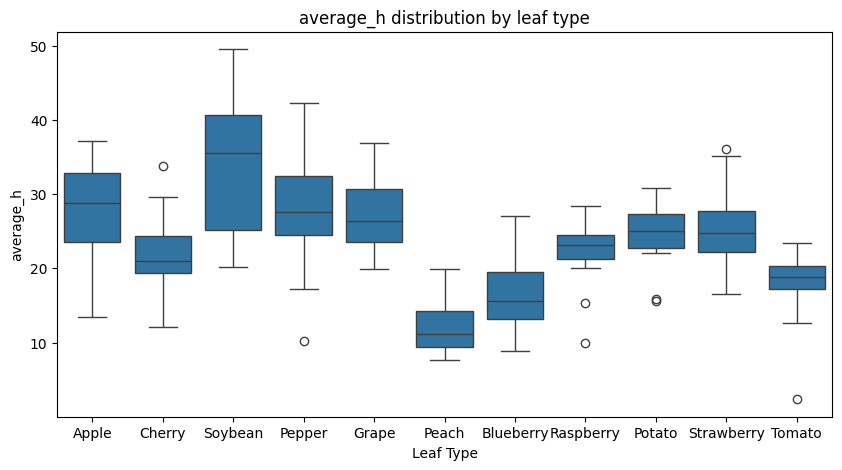

'\n# display single lbp histogram\nlbpn = features[\'Apple\'][0][\'lbp_hist\']\nplt.bar(range(len(lbpn)), lbpn)\nplt.title("LBP HISTOGRAM")\nplt.show()\n'

In [299]:
########################
#@title Test / Display
import seaborn as sns

features = dict()
def show_5(leaf_type):
    features[leaf_type] = []
    total = 30
    if leaf_type == 'Corn': return # removed because not in desired model behavior
    #if leaf_type != "Peach": return
    print(f'{leaf_type}')
    for i in range(total-1):
        img = orig_leaves[leaf_type][i].copy()
        bin_img = binary_leaf_hsv(img)
        features[leaf_type].append(extract_features(bin_img, img))

        ## Plot shown in README
        #plt.subplot(2, 3, 1)
        #plt.imshow(img)
        #plt.subplot(2, 3, 3)
        #plt.imshow(bin_img, cmap="gray")
    #plt.show()



for leaf_type in orig_leaves:
    show_5(leaf_type)

features_to_show = ['area', 'perimeter', 'solidity', 'major_axis_length', 'minor_axis_length', 'aspect_ratio', \
                    'contrast', 'homogeneity', \
                    'gabor_mean_max', 'gabor_std_max', 'average_h']
for feature_type in features_to_show:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=[key for key in features.keys() for _ in range(len(features[key]))], y=[value[feature_type] for key in features.keys() for value in features[key]])
    plt.xlabel('Leaf Type')
    plt.ylabel(feature_type)
    plt.title(str(feature_type) + ' distribution by leaf type')
    plt.show()
'''
# display single lbp histogram
lbpn = features['Apple'][0]['lbp_hist']
plt.bar(range(len(lbpn)), lbpn)
plt.title("LBP HISTOGRAM")
plt.show()
'''
